In [1]:
import sys

sys.path.append("../../")

import importlib, NB_config

importlib.reload(NB_config)
from NB_config import *

In [2]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
cities = pd.read_csv(CITIES_META_PATH, low_memory=False)

In [8]:
dummy_cols = [col for col in df.columns if col.startswith('entity_type_')]
df['entity_type'] = df[dummy_cols].idxmax(axis=1).str.replace('entity_type_', '')
df.loc[df[dummy_cols].sum(axis=1) == 0, 'entity_type'] = 'attraction'
print(df['entity_type'].value_counts())

entity_type
hotel         126599
restaurant     18085
attraction      4801
Name: count, dtype: int64


In [3]:
print(df.columns)

Index(['name', 'city', 'country', 'country_name', 'continent', 'latitude',
       'longitude', 'stars', 'review_count', 'description', 'popularity',
       'attr_wheelchair', 'attr_fee', 'attr_internet_access', 'attr_smoking',
       'attr_air_conditioning', 'attr_takeaway', 'attr_capacity',
       'attr_delivery', 'attr_outdoor_seating', 'attr_diet_vegetarian',
       'attr_diet_vegan', 'has_any_attributes', 'categories_clean',
       'description_clean', 'desc_len', 'desc_score', 'cat_count', 'cat_score',
       'quality_score', 'stars_norm', 'review_count_norm', 'popularity_norm',
       'missing_description', 'missing_location', 'source_openstreetmap',
       'source_tbo_hotels', 'source_tripadvisor', 'entity_type_hotel',
       'entity_type_restaurant', 'country_grouped_AU', 'country_grouped_CA',
       'country_grouped_DE', 'country_grouped_ES', 'country_grouped_FR',
       'country_grouped_GB', 'country_grouped_HK', 'country_grouped_ID',
       'country_grouped_IN', 'country_gro

<Axes: xlabel='stars', ylabel='Count'>

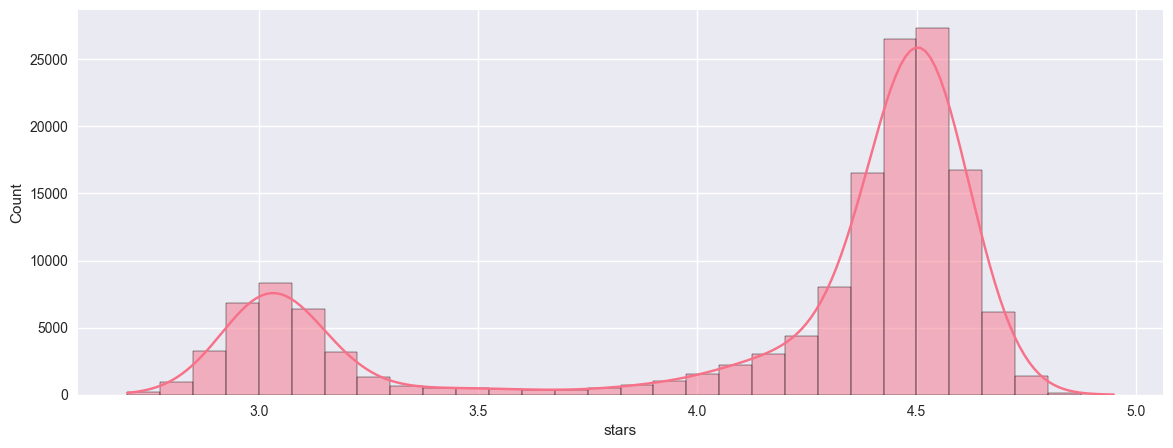

In [9]:
sns.histplot(df["stars"], bins=30, kde=True)

<Axes: xlabel='entity_type', ylabel='stars'>

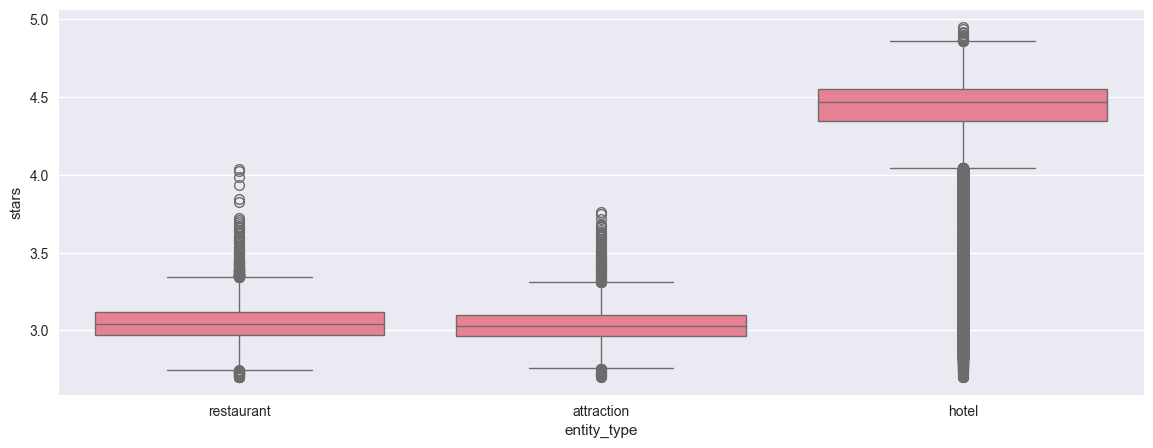

In [10]:
sns.boxplot(data=df, x="entity_type", y="stars")

In [11]:
df["popularity_score"] = df["stars"] * np.log1p(df["review_count"])

In [16]:
df.nlargest(10, "popularity_score")[["name", "stars", "review_count"]]

,name,stars,review_count
32149,Villa Verde Gatwick,4.661848,59084
100119,Zanzibar Locke,4.659168,57554
28275,Tsq Whitehall,4.749194,43310
87317,San Giusto,4.400258,90726
91500,Neo Hotel,4.783751,33585
119759,Hotel Boutique Royal Classy,4.544464,57335
43646,Suo Fan Ni,4.696144,39753
104889,dAlang Alang Villas,4.598200,49688
67064,The Sea At Your Fingertips,4.516697,58731
119889,Girardot Resort Apto102,4.664750,38970


<Axes: xlabel='review_count', ylabel='popularity'>

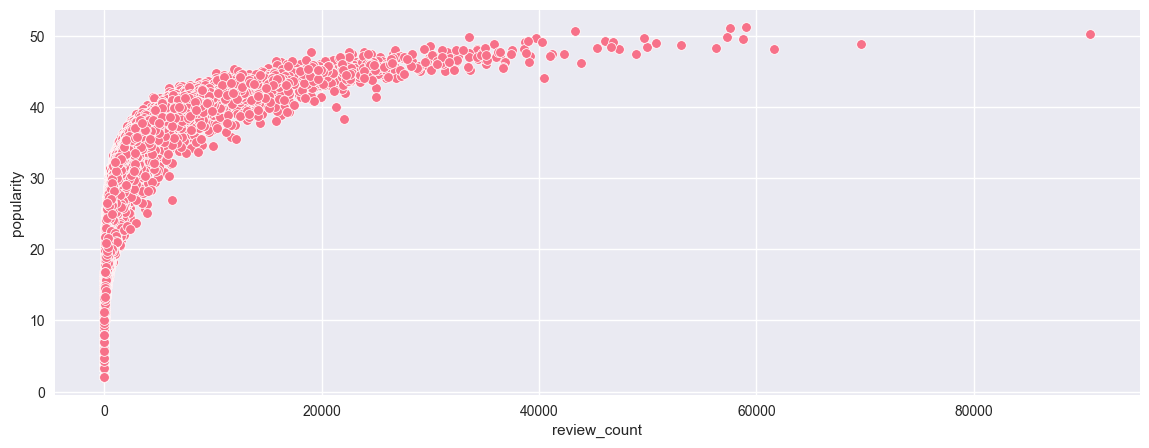

In [17]:
sns.scatterplot(data=df, x="review_count", y="popularity")

In [18]:
df[["stars", "review_count", "popularity_score"]].corr()

,stars,review_count,popularity_score
stars,1.000000,0.323600,0.879494
review_count,0.323600,1.000000,0.610071
popularity_score,0.879494,0.610071,1.000000


In [19]:
high_reviews = df[df["review_count"] > df["review_count"].quantile(0.9)]
low_reviews = df[df["review_count"] < df["review_count"].quantile(0.1)]

In [20]:
X = df[["review_count"]]
y = df["stars"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


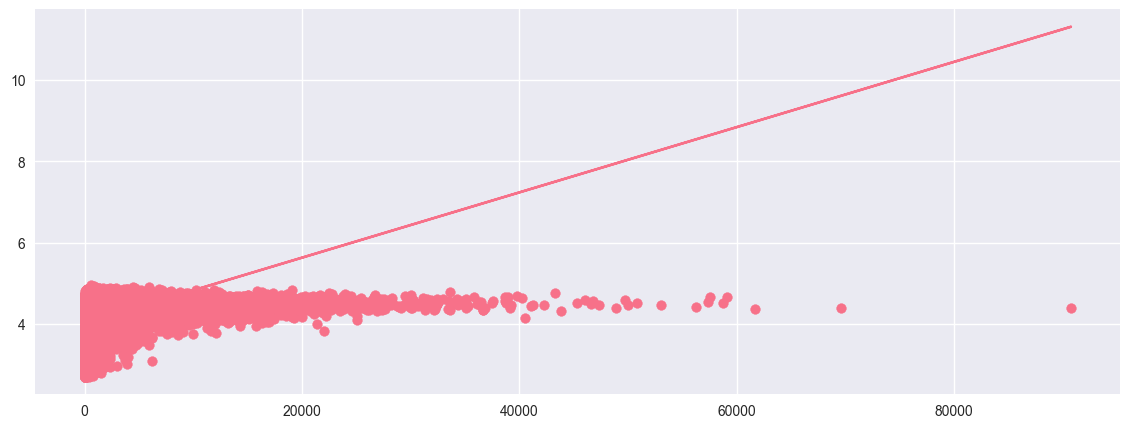

In [21]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))